In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import os
import glob
import zipfile
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    accuracy_score,
    f1_score,
    roc_curve
)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ================================
# PATHS
# ================================

ZIP_PATH = "/content/drive/MyDrive/Colab Notebooks/Parkinson_project_using_mobile_net_V2_inclue_F_base_T_F_/Parkinson_dataset.zip"

UNZIP_DIR = "/content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_UNZIP_HERE"

SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE"

MODEL_DIR = os.path.join(SAVE_DIR, "models")
HISTORY_DIR = os.path.join(SAVE_DIR, "history_files")
GRAPH_DIR = os.path.join(SAVE_DIR, "graphs")
CM_DIR = os.path.join(SAVE_DIR, "confusion_matrices")
REPORT_DIR = os.path.join(SAVE_DIR, "reports")
GRADCAM_DIR = os.path.join(SAVE_DIR, "gradcam_heatmaps")

for d in [UNZIP_DIR, SAVE_DIR, MODEL_DIR, HISTORY_DIR, GRAPH_DIR, CM_DIR, REPORT_DIR, GRADCAM_DIR]:
    os.makedirs(d, exist_ok=True)

print("ZIP_PATH:", ZIP_PATH)
print("UNZIP_DIR:", UNZIP_DIR)
print("SAVE_DIR:", SAVE_DIR)

ZIP_PATH: /content/drive/MyDrive/Colab Notebooks/Parkinson_project_using_mobile_net_V2_inclue_F_base_T_F_/Parkinson_dataset.zip
UNZIP_DIR: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_UNZIP_HERE
SAVE_DIR: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE


In [ ]:
# ================================
# UNZIP DATASET
# ================================

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"ZIP file not found: {ZIP_PATH}")

expected_extracted_dir = os.path.join(UNZIP_DIR, "Parkinson_dataset")

if not os.path.exists(expected_extracted_dir) or not os.listdir(expected_extracted_dir):
    print(f"Unzipping dataset to {UNZIP_DIR}...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(UNZIP_DIR)
    print("Dataset unzipped to:", UNZIP_DIR)
else:
    print("Dataset already unzipped at:", expected_extracted_dir)

print("\nContents of UNZIP_DIR:")
for item in os.listdir(UNZIP_DIR):
    print(os.path.join(UNZIP_DIR, item))

Unzipping dataset to /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_UNZIP_HERE...
Dataset unzipped to: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_UNZIP_HERE

Contents of UNZIP_DIR:
/content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_UNZIP_HERE/Parkinson_dataset


In [ ]:
# ================================
# FIND IMAGE FILES
# ================================

image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff"]

all_images = []

for ext in image_extensions:
    all_images.extend(
        glob.glob(os.path.join(expected_extracted_dir, "**", ext), recursive=True)
    )

print("Total images found:", len(all_images))

if len(all_images) == 0:
    raise ValueError("No images found. Check dataset folder structure.")

print("\nSample image paths:")
for p in all_images[:10]:
    print(p)


# ================================
# CREATE DATAFRAME
# ================================

data = []

for img_path in all_images:
    lower_path = img_path.lower()

    if "healthy" in lower_path or "normal" in lower_path or "control" in lower_path:
        label = 0
        data.append([img_path, label])

    elif "parkinson" in lower_path or "pd" in lower_path:
        label = 1
        data.append([img_path, label])

df = pd.DataFrame(data, columns=["image_path", "label"])

print("\nTotal labeled images:", len(df))
print(df.head())

print("\nClass counts:")
print(df["label"].value_counts())

if len(df) == 0:
    raise ValueError("No labeled images found. Folder names should contain healthy/control/normal or parkinson/pd.")

if df["label"].nunique() != 2:
    raise ValueError("Both classes not found. Need Healthy and Parkinson images.")

Total images found: 11120

Sample image paths:
/content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_UNZIP_HERE/Parkinson_dataset/healthy_dataset/control_png/PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_000.png
/content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_UNZIP_HERE/Parkinson_dataset/healthy_dataset/control_png/PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_001.png
/content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_UNZIP_HERE/Parkinson_dataset/healthy_dataset/control_png/PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_002.png
/content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_UNZIP_HERE/Parkinson_dataset/healthy_dataset/control_png/PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_003.png
/content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_UNZIP_HERE/Parkinson_dataset/

In [ ]:
# ================================
# SPLIT DATASET
# ================================

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain counts:")
print(train_df["label"].value_counts())

print("\nValidation counts:")
print(val_df["label"].value_counts())

print("\nTest counts:")
print(test_df["label"].value_counts())

Train shape: (7784, 2)
Validation shape: (1668, 2)
Test shape: (1668, 2)

Train counts:
label
1    3892
0    3892
Name: count, dtype: int64

Validation counts:
label
0    834
1    834
Name: count, dtype: int64

Test counts:
label
0    834
1    834
Name: count, dtype: int64


In [ ]:
# ================================
# IMAGE GENERATORS
# ================================

IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS = 35

train_df["label"] = train_df["label"].astype(str)
val_df["label"] = val_df["label"].astype(str)
test_df["label"] = test_df["label"].astype(str)

train_datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", train_gen.class_indices)

Found 7784 validated image filenames belonging to 2 classes.
Found 1668 validated image filenames belonging to 2 classes.
Found 1668 validated image filenames belonging to 2 classes.
Class indices: {'0': 0, '1': 1}


In [ ]:
# ================================
# MODEL A: VGG16 + MOBILENETV2 CONCATENATION FUSION
# ================================

def build_vgg16_mobilenet_concat_model(base_trainable=True):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="mri_input")

    # Branch-specific preprocessing
    vgg_input = layers.Lambda(
        lambda x: vgg16_preprocess(x),
        name="vgg16_preprocessing"
    )(inputs)

    mobile_input = layers.Lambda(
        lambda x: mobilenet_preprocess(x),
        name="mobilenetv2_preprocessing"
    )(inputs)

    # VGG16 backbone
    raw_vgg = VGG16(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    vgg_backbone = keras.Model(
        inputs=raw_vgg.input,
        outputs=raw_vgg.output,
        name="vgg16_backbone"
    )

    vgg_backbone.trainable = base_trainable

    # MobileNetV2 backbone
    raw_mobile = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    mobilenet_backbone = keras.Model(
        inputs=raw_mobile.input,
        outputs=raw_mobile.output,
        name="mobilenetv2_backbone"
    )

    mobilenet_backbone.trainable = base_trainable

    # Feature maps
    vgg_features = vgg_backbone(vgg_input)
    mobile_features = mobilenet_backbone(mobile_input)

    # Feature vectors
    vgg_vector = layers.GlobalAveragePooling2D(name="vgg16_gap")(vgg_features)
    mobile_vector = layers.GlobalAveragePooling2D(name="mobilenetv2_gap")(mobile_features)

    # Early fusion by concatenation
    fused = layers.Concatenate(name="early_fusion_concatenation")(
        [vgg_vector, mobile_vector]
    )

    x = layers.Dense(512, activation="relu")(fused)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation="sigmoid", name="prediction")(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="VGG16_MobileNetV2_Early_Fusion_Concatenation"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [ ]:
# ================================
# MODEL B: VGG16 + MOBILENETV2 ATTENTION FUSION
# ================================

def build_vgg16_mobilenet_attention_model(base_trainable=True):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="mri_input")

    # Branch-specific preprocessing
    vgg_input = layers.Lambda(
        lambda x: vgg16_preprocess(x),
        name="vgg16_preprocessing"
    )(inputs)

    mobile_input = layers.Lambda(
        lambda x: mobilenet_preprocess(x),
        name="mobilenetv2_preprocessing"
    )(inputs)

    # VGG16 backbone
    raw_vgg = VGG16(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    vgg_backbone = keras.Model(
        inputs=raw_vgg.input,
        outputs=raw_vgg.output,
        name="vgg16_backbone"
    )

    vgg_backbone.trainable = base_trainable

    # MobileNetV2 backbone
    raw_mobile = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    mobilenet_backbone = keras.Model(
        inputs=raw_mobile.input,
        outputs=raw_mobile.output,
        name="mobilenetv2_backbone"
    )

    mobilenet_backbone.trainable = base_trainable

    # Feature maps
    vgg_features = vgg_backbone(vgg_input)
    mobile_features = mobilenet_backbone(mobile_input)

    # Feature vectors
    vgg_vector = layers.GlobalAveragePooling2D(name="vgg16_gap")(vgg_features)
    mobile_vector = layers.GlobalAveragePooling2D(name="mobilenetv2_gap")(mobile_features)

    # Project both feature vectors to same size
    vgg_projected = layers.Dense(256, activation="relu", name="vgg16_projected")(vgg_vector)
    mobile_projected = layers.Dense(256, activation="relu", name="mobilenetv2_projected")(mobile_vector)

    # Attention input
    combined_features = layers.Concatenate(name="attention_input")(
        [vgg_projected, mobile_projected]
    )

    # Learnable attention weights
    attention_weights = layers.Dense(
        2,
        activation="softmax",
        name="branch_attention_weights"
    )(combined_features)

    # Apply attention weights
    weighted_vgg = layers.Lambda(
        lambda x: x[0] * x[1][:, 0:1],
        name="weighted_vgg16_features"
    )([vgg_projected, attention_weights])

    weighted_mobile = layers.Lambda(
        lambda x: x[0] * x[1][:, 1:2],
        name="weighted_mobilenetv2_features"
    )([mobile_projected, attention_weights])

    # Early fusion by attention
    fused = layers.Add(name="early_fusion_attention")(
        [weighted_vgg, weighted_mobile]
    )

    x = layers.Dense(256, activation="relu")(fused)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation="sigmoid", name="prediction")(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="VGG16_MobileNetV2_Early_Fusion_Attention"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [ ]:
# ================================
# GRAPH FUNCTION
# ================================

def plot_training_history(history, model_name):
    hist = history.history
    epochs = range(1, len(hist["accuracy"]) + 1)

    # Accuracy graph
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["accuracy"], marker="o", label="Train Accuracy")
    plt.plot(epochs, hist["val_accuracy"], marker="o", label="Validation Accuracy")
    plt.title(f"{model_name} - Accuracy vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    acc_path = os.path.join(GRAPH_DIR, f"{model_name}_accuracy_vs_epochs.png")
    plt.savefig(acc_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", acc_path)

    # Loss graph
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["loss"], marker="o", label="Train Loss")
    plt.plot(epochs, hist["val_loss"], marker="o", label="Validation Loss")
    plt.title(f"{model_name} - Loss vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    loss_path = os.path.join(GRAPH_DIR, f"{model_name}_loss_vs_epochs.png")
    plt.savefig(loss_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", loss_path)

    # AUC graph
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["auc"], marker="o", label="Train AUC")
    plt.plot(epochs, hist["val_auc"], marker="o", label="Validation AUC")
    plt.title(f"{model_name} - AUC vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("AUC")
    plt.legend()
    plt.grid(True)

    auc_path = os.path.join(GRAPH_DIR, f"{model_name}_auc_vs_epochs.png")
    plt.savefig(auc_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", auc_path)

In [ ]:
# ================================
# EVALUATION FUNCTION
# ================================

def evaluate_model(model, test_gen, model_name):
    test_gen.reset()

    y_prob = model.predict(test_gen).ravel()
    y_pred = (y_prob > 0.5).astype(int)
    y_true = test_gen.classes

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    print("\n==============================")
    print(model_name)
    print("==============================")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("ROC AUC:", auc)

    report = classification_report(
        y_true,
        y_pred,
        target_names=["Healthy", "Parkinson"]
    )

    print("\nClassification Report:")
    print(report)

    cm = confusion_matrix(y_true, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # Save report
    report_path = os.path.join(REPORT_DIR, f"{model_name}_classification_report.txt")

    with open(report_path, "w") as f:
        f.write(f"Model: {model_name}\n")
        f.write(f"Accuracy: {acc}\n")
        f.write(f"F1 Score: {f1}\n")
        f.write(f"ROC AUC: {auc}\n\n")
        f.write("Classification Report:\n")
        f.write(report)
        f.write("\nConfusion Matrix:\n")
        f.write(str(cm))

    print("Report saved:", report_path)

    # Save confusion matrix CSV
    cm_df = pd.DataFrame(
        cm,
        index=["Actual Healthy", "Actual Parkinson"],
        columns=["Predicted Healthy", "Predicted Parkinson"]
    )

    cm_csv_path = os.path.join(CM_DIR, f"{model_name}_confusion_matrix.csv")
    cm_df.to_csv(cm_csv_path)
    print("Confusion matrix CSV saved:", cm_csv_path)

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Healthy", "Parkinson"]
    )
    disp.plot(values_format="d", ax=ax)
    plt.title(f"{model_name} - Confusion Matrix")

    cm_png_path = os.path.join(CM_DIR, f"{model_name}_confusion_matrix.png")
    plt.savefig(cm_png_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Confusion matrix image saved:", cm_png_path)

    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.title(f"{model_name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)

    roc_path = os.path.join(GRAPH_DIR, f"{model_name}_roc_curve.png")
    plt.savefig(roc_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("ROC curve saved:", roc_path)

    return {
        "model_name": model_name,
        "accuracy": acc,
        "f1_score": f1,
        "roc_auc": auc
    }

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_MobileNetV2_Early_Fusion_Concatenation"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mri_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_preprocessing │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_prepro… │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_backbone      │ (None, 7, 7, 512) │ 14,714,688 │ vgg16_preprocess… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_backbo… │ (None, 7, 7,      │  2,257,984 │ mobilenetv2_prep… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_gap           │ (None, 512)       │          0 │ vgg16_backbone[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_gap     │ (None, 1280)      │          0 │ mobilenetv2_back… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ early_fusion_conca… │ (None, 1792)      │          0 │ vgg16_gap[0][0],  │
│ (Concatenate)       │                   │            │ mobilenetv2_gap[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    918,016 │ early_fusion_con… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction (Dense)  │ (None, 1)         │        129 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 18,058,625 (68.89 MB)

 Trainable params: 18,022,721 (68.75 MB)

 Non-trainable params: 35,904 (140.25 KB)

Epoch 1/35
973/973 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.5290 - auc: 0.5426 - loss: 0.8902
Epoch 1: val_auc improved from None to 0.65655, saving model to /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/models/VGG16_MobileNetV2_Early_Fusion_Concatenation_base_trainable_true_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/models/VGG16_MobileNetV2_Early_Fusion_Concatenation_base_trainable_true_best.keras
973/973 ━━━━━━━━━━━━━━━━━━━━ 372s 292ms/step - accuracy: 0.5324 - auc: 0.5482 - loss: 0.8808 - val_accuracy: 0.5216 - val_auc: 0.6566 - val_loss: 1.9057 - learning_rate: 1.0000e-05
Epoch 2/35
973/973 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.5549 - auc: 0.5806 - loss: 0.8353
Epoch 2: val_auc did not improve from 0.65655
973/973 ━━━━━━━━━━━━━━━━━━━━ 219s 225ms/step - accuracy: 0.5586 - auc: 0.5873 - loss: 0.8261 - val_accuracy: 0.5000 - val_auc: 0.5427 - va

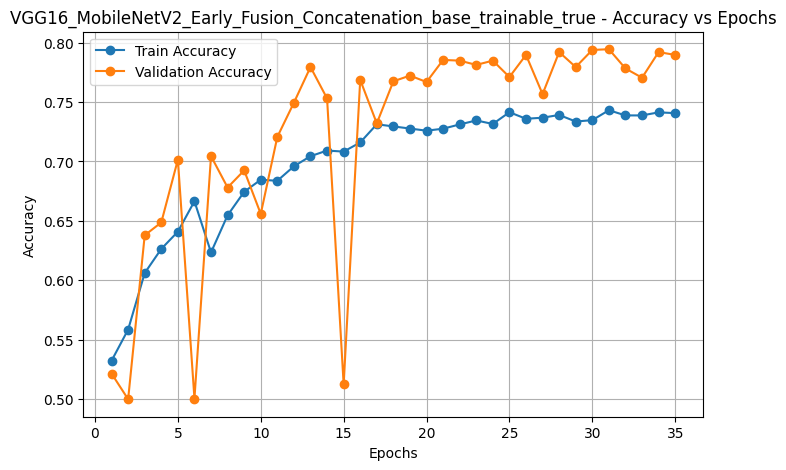

Saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/graphs/VGG16_MobileNetV2_Early_Fusion_Concatenation_base_trainable_true_accuracy_vs_epochs.png


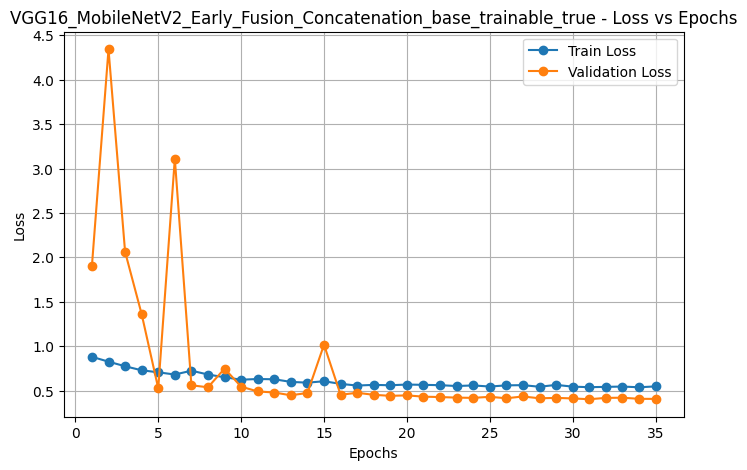

Saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/graphs/VGG16_MobileNetV2_Early_Fusion_Concatenation_base_trainable_true_loss_vs_epochs.png


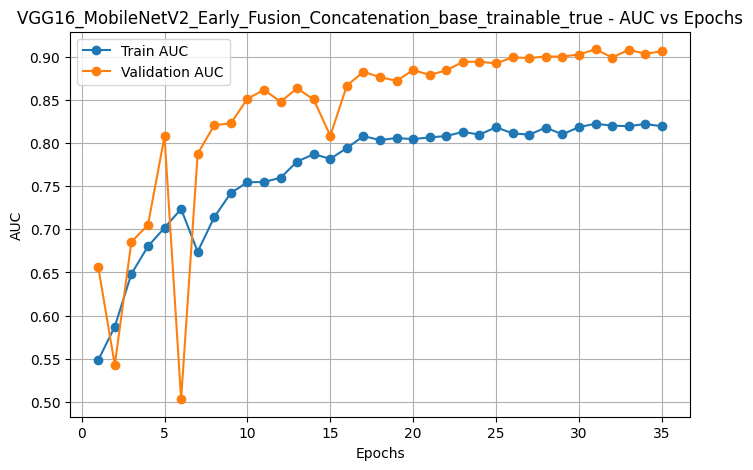

Saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/graphs/VGG16_MobileNetV2_Early_Fusion_Concatenation_base_trainable_true_auc_vs_epochs.png
209/209 ━━━━━━━━━━━━━━━━━━━━ 24s 88ms/step

VGG16_MobileNetV2_Early_Fusion_Concatenation_base_trainable_true
Accuracy: 0.7985611510791367
F1 Score: 0.7803921568627451
ROC AUC: 0.9084099626773401

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.76      0.88      0.81       834
   Parkinson       0.86      0.72      0.78       834

    accuracy                           0.80      1668
   macro avg       0.81      0.80      0.80      1668
weighted avg       0.81      0.80      0.80      1668


Confusion Matrix:
[[735  99]
 [237 597]]
Report saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/reports/VGG16_MobileNetV2_Early_Fusion_Concatenation_base_trainable_true_classification_report.txt
Confusion matrix CSV saved: /content

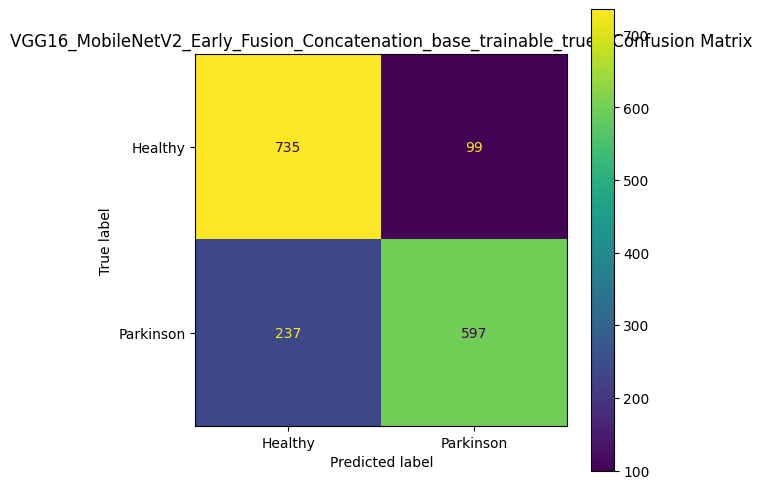

Confusion matrix image saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/confusion_matrices/VGG16_MobileNetV2_Early_Fusion_Concatenation_base_trainable_true_confusion_matrix.png


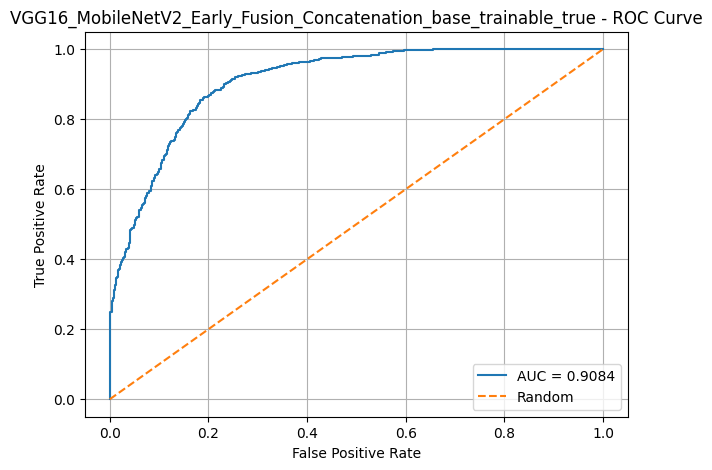

ROC curve saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/graphs/VGG16_MobileNetV2_Early_Fusion_Concatenation_base_trainable_true_roc_curve.png


In [ ]:
# ================================
# TRAIN MODEL A: CONCATENATION FUSION
# ================================

model_name_concat = "VGG16_MobileNetV2_Early_Fusion_Concatenation_base_trainable_true"

concat_model = build_vgg16_mobilenet_concat_model(base_trainable=True)

concat_model.summary()

callbacks_concat = [
    EarlyStopping(
        monitor="val_auc",
        patience=7,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, f"{model_name_concat}_best.keras"),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    CSVLogger(
        filename=os.path.join(HISTORY_DIR, f"{model_name_concat}_training_log.csv")
    )
]

history_concat = concat_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks_concat
)

# Save final model
concat_final_path = os.path.join(MODEL_DIR, f"{model_name_concat}_final.keras")
concat_model.save(concat_final_path)
print("Final model saved:", concat_final_path)

# Save history JSON
history_concat_path = os.path.join(HISTORY_DIR, f"{model_name_concat}_history.json")

with open(history_concat_path, "w") as f:
    json.dump(history_concat.history, f)

print("History saved:", history_concat_path)

# Plot graphs
plot_training_history(history_concat, model_name_concat)

# Evaluate model
results_concat = evaluate_model(concat_model, test_gen, model_name_concat)

Model: "VGG16_MobileNetV2_Early_Fusion_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mri_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_preprocessing │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_prepro… │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_backbone      │ (None, 7, 7, 512) │ 14,714,688 │ vgg16_preprocess… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_backbo… │ (None, 7, 7,      │  2,257,984 │ mobilenetv2_prep… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_gap           │ (None, 512)       │          0 │ vgg16_backbone[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_gap     │ (None, 1280)      │          0 │ mobilenetv2_back… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_projected     │ (None, 256)       │    131,328 │ vgg16_gap[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_projec… │ (None, 256)       │    327,936 │ mobilenetv2_gap[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_input     │ (None, 512)       │          0 │ vgg16_projected[… │
│ (Concatenate)       │                   │            │ mobilenetv2_proj… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_attention_w… │ (None, 2)         │      1,026 │ attention_input[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weighted_vgg16_fea… │ (None, 256)       │          0 │ vgg16_projected[… │
│ (Lambda)            │                   │            │ branch_attention… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weighted_mobilenet… │ (None, 256)       │          0 │ mobilenetv2_proj… │
│ (Lambda)            │                   │            │ branch_attention… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ early_fusion_atten… │ (None, 256)       │          0 │ weighted_vgg16_f… │
│ (Add)               │                   │            │ weighted_mobilen… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     65,792 │ early_fusion_att… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 17,533,315 (66.88 MB)

 Trainable params: 17,498,435 (66.75 MB)

 Non-trainable params: 34,880 (136.25 KB)

Epoch 1/35
973/973 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.5463 - auc: 0.5625 - loss: 0.8675
Epoch 1: val_auc improved from None to 0.68069, saving model to /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/models/VGG16_MobileNetV2_Early_Fusion_Attention_base_trainable_true_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/models/VGG16_MobileNetV2_Early_Fusion_Attention_base_trainable_true_best.keras
973/973 ━━━━━━━━━━━━━━━━━━━━ 290s 235ms/step - accuracy: 0.5788 - auc: 0.6088 - loss: 0.8114 - val_accuracy: 0.5965 - val_auc: 0.6807 - val_loss: 0.7785 - learning_rate: 1.0000e-05
Epoch 2/35
973/973 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.6369 - auc: 0.6834 - loss: 0.7324
Epoch 2: val_auc improved from 0.68069 to 0.72059, saving model to /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/models/VGG16_MobileNetV2_Early_Fusion_Atte

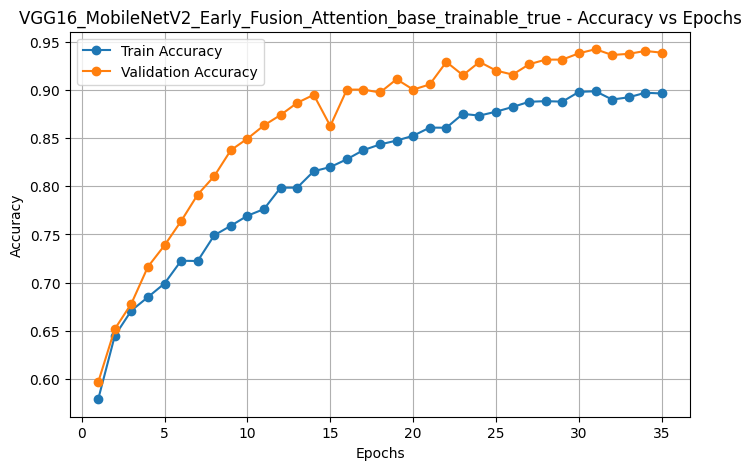

Saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/graphs/VGG16_MobileNetV2_Early_Fusion_Attention_base_trainable_true_accuracy_vs_epochs.png


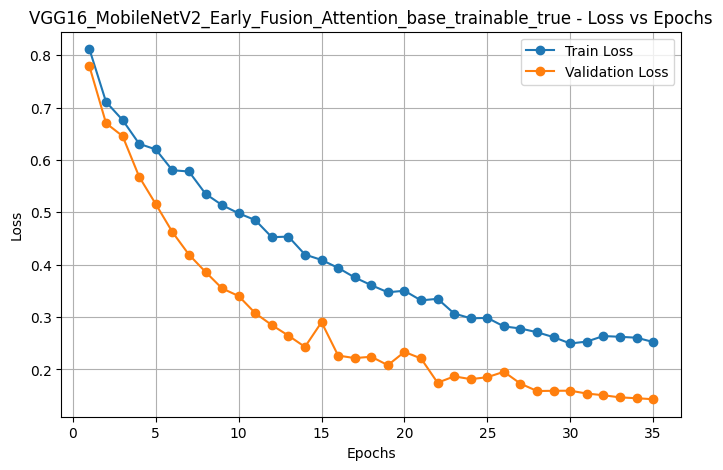

Saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/graphs/VGG16_MobileNetV2_Early_Fusion_Attention_base_trainable_true_loss_vs_epochs.png


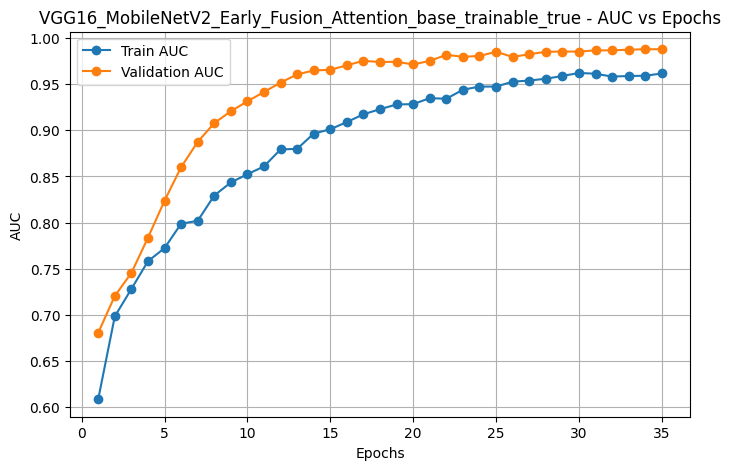

Saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/graphs/VGG16_MobileNetV2_Early_Fusion_Attention_base_trainable_true_auc_vs_epochs.png
209/209 ━━━━━━━━━━━━━━━━━━━━ 23s 87ms/step

VGG16_MobileNetV2_Early_Fusion_Attention_base_trainable_true
Accuracy: 0.9556354916067147
F1 Score: 0.9558998808104887
ROC AUC: 0.9929380236817741

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.96      0.95      0.96       834
   Parkinson       0.95      0.96      0.96       834

    accuracy                           0.96      1668
   macro avg       0.96      0.96      0.96      1668
weighted avg       0.96      0.96      0.96      1668


Confusion Matrix:
[[792  42]
 [ 32 802]]
Report saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/reports/VGG16_MobileNetV2_Early_Fusion_Attention_base_trainable_true_classification_report.txt
Confusion matrix CSV saved: /content/drive/MyDri

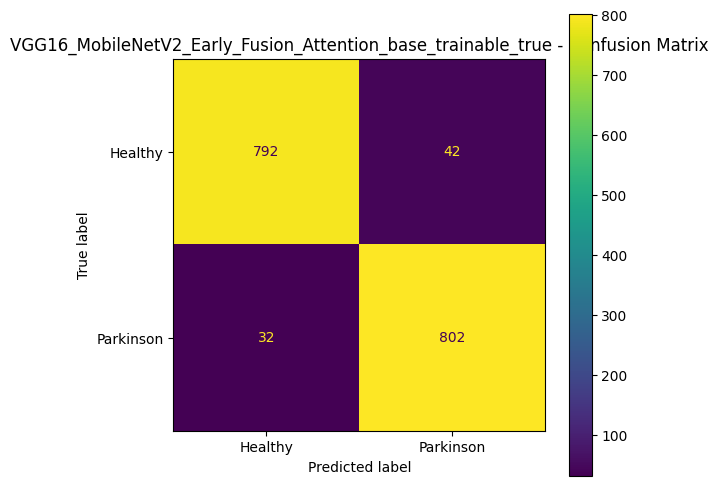

Confusion matrix image saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/confusion_matrices/VGG16_MobileNetV2_Early_Fusion_Attention_base_trainable_true_confusion_matrix.png


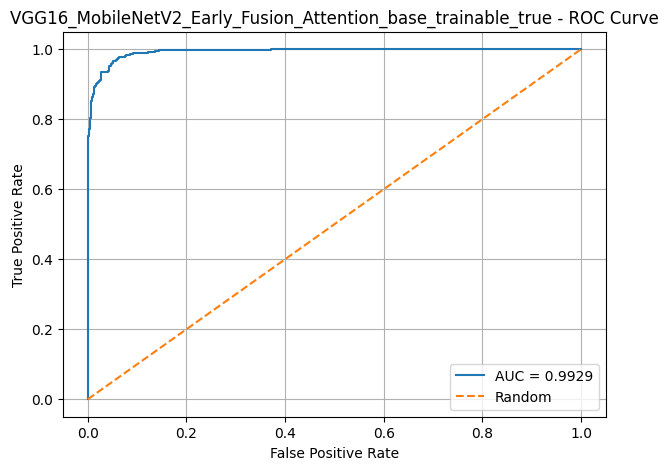

ROC curve saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/graphs/VGG16_MobileNetV2_Early_Fusion_Attention_base_trainable_true_roc_curve.png


In [ ]:
# ================================
# TRAIN MODEL B: ATTENTION FUSION
# ================================

model_name_attention = "VGG16_MobileNetV2_Early_Fusion_Attention_base_trainable_true"

attention_model = build_vgg16_mobilenet_attention_model(base_trainable=True)

attention_model.summary()

callbacks_attention = [
    EarlyStopping(
        monitor="val_auc",
        patience=7,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, f"{model_name_attention}_best.keras"),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    CSVLogger(
        filename=os.path.join(HISTORY_DIR, f"{model_name_attention}_training_log.csv")
    )
]

history_attention = attention_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks_attention
)

# Save final model
attention_final_path = os.path.join(MODEL_DIR, f"{model_name_attention}_final.keras")
attention_model.save(attention_final_path)
print("Final model saved:", attention_final_path)

# Save history JSON
history_attention_path = os.path.join(HISTORY_DIR, f"{model_name_attention}_history.json")

with open(history_attention_path, "w") as f:
    json.dump(history_attention.history, f)

print("History saved:", history_attention_path)

# Plot graphs
plot_training_history(history_attention, model_name_attention)

# Evaluate model
results_attention = evaluate_model(attention_model, test_gen, model_name_attention)

In [ ]:
# ================================
# COMPARE BOTH FUSION MODELS
# ================================

fusion_comparison_df = pd.DataFrame([
    {
        "Model": results_concat["model_name"],
        "Fusion Method": "Concatenation",
        "Backbones": "VGG16 + MobileNetV2",
        "include_top": False,
        "base_trainable": True,
        "Accuracy": results_concat["accuracy"],
        "F1 Score": results_concat["f1_score"],
        "ROC AUC": results_concat["roc_auc"]
    },
    {
        "Model": results_attention["model_name"],
        "Fusion Method": "Attention",
        "Backbones": "VGG16 + MobileNetV2",
        "include_top": False,
        "base_trainable": True,
        "Accuracy": results_attention["accuracy"],
        "F1 Score": results_attention["f1_score"],
        "ROC AUC": results_attention["roc_auc"]
    }
])

comparison_path = os.path.join(REPORT_DIR, "vgg16_mobilenetv2_early_fusion_comparison.csv")
fusion_comparison_df.to_csv(comparison_path, index=False)

print("Comparison saved:", comparison_path)
fusion_comparison_df

Comparison saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/reports/vgg16_mobilenetv2_early_fusion_comparison.csv


,Model,Fusion Method,Backbones,include_top,base_trainable,Accuracy,F1 Score,ROC AUC
0,VGG16_MobileNetV2_Early_Fusion_Concatenation_b...,Concatenation,VGG16 + MobileNetV2,False,True,0.798561,0.780392,0.908410
1,VGG16_MobileNetV2_Early_Fusion_Attention_base_...,Attention,VGG16 + MobileNetV2,False,True,0.955635,0.955900,0.992938


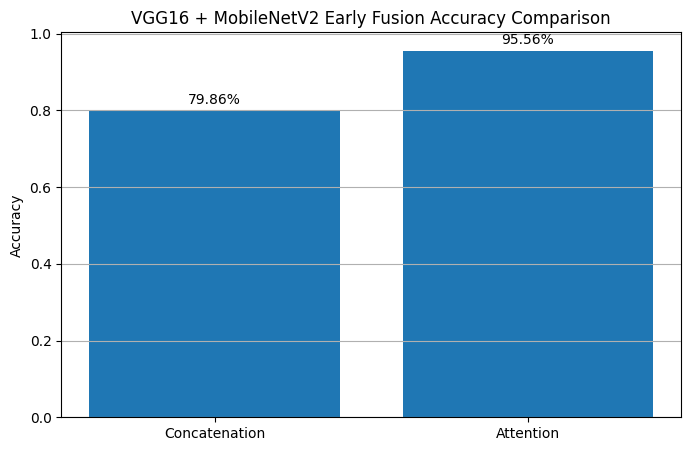

Saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/graphs/vgg16_mobilenetv2_fusion_accuracy_comparison.png


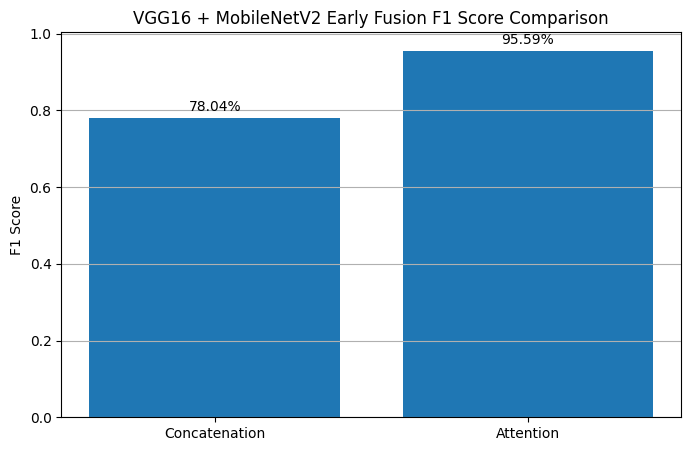

Saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/graphs/vgg16_mobilenetv2_fusion_f1_comparison.png


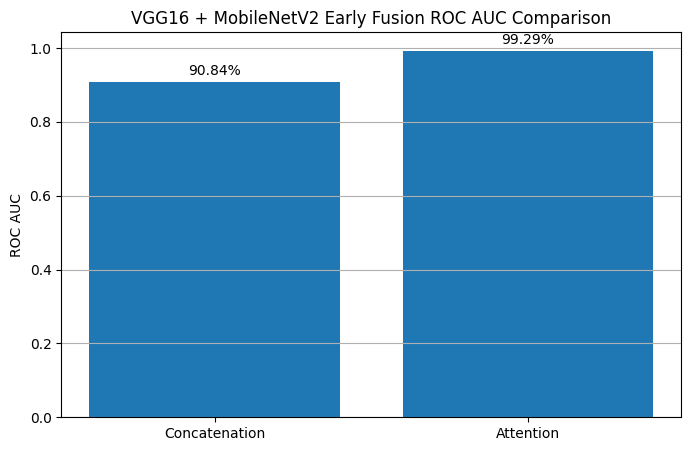

Saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/graphs/vgg16_mobilenetv2_fusion_auc_comparison.png


In [ ]:
# ================================
# COMPARISON GRAPHS
# ================================

# Accuracy comparison
plt.figure(figsize=(8, 5))
bars = plt.bar(fusion_comparison_df["Fusion Method"], fusion_comparison_df["Accuracy"])
plt.title("VGG16 + MobileNetV2 Early Fusion Accuracy Comparison")
plt.ylabel("Accuracy")
plt.grid(axis="y")

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.01,
        f"{yval:.2%}",
        ha="center",
        va="bottom"
    )

acc_compare_path = os.path.join(GRAPH_DIR, "vgg16_mobilenetv2_fusion_accuracy_comparison.png")
plt.savefig(acc_compare_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", acc_compare_path)


# F1 comparison
plt.figure(figsize=(8, 5))
bars = plt.bar(fusion_comparison_df["Fusion Method"], fusion_comparison_df["F1 Score"])
plt.title("VGG16 + MobileNetV2 Early Fusion F1 Score Comparison")
plt.ylabel("F1 Score")
plt.grid(axis="y")

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.01,
        f"{yval:.2%}",
        ha="center",
        va="bottom"
    )

f1_compare_path = os.path.join(GRAPH_DIR, "vgg16_mobilenetv2_fusion_f1_comparison.png")
plt.savefig(f1_compare_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", f1_compare_path)


# ROC AUC comparison
plt.figure(figsize=(8, 5))
bars = plt.bar(fusion_comparison_df["Fusion Method"], fusion_comparison_df["ROC AUC"])
plt.title("VGG16 + MobileNetV2 Early Fusion ROC AUC Comparison")
plt.ylabel("ROC AUC")
plt.grid(axis="y")

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.01,
        f"{yval:.2%}",
        ha="center",
        va="bottom"
    )

auc_compare_path = os.path.join(GRAPH_DIR, "vgg16_mobilenetv2_fusion_auc_comparison.png")
plt.savefig(auc_compare_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", auc_compare_path)

In [ ]:
# ================================
# GRAD-CAM FUNCTIONS FOR VGG16 + MOBILENETV2 FUSION MODEL
# ================================

def normalize_heatmap(heatmap):
    heatmap = np.maximum(heatmap, 0)
    max_value = np.max(heatmap)

    if max_value == 0:
        return heatmap

    return heatmap / max_value


def compute_branch_gradcam(model, img_array, branch_name, target_class=None):
    """
    Correct Grad-CAM for VGG16 + MobileNetV2 fusion model.

    branch_name should be:
    - 'vgg16_backbone'
    - 'mobilenetv2_backbone'
    """

    # Use connected tensors from the main fusion model
    if branch_name == "vgg16_backbone":
        feature_map_tensor = model.get_layer("vgg16_gap").input

    elif branch_name == "mobilenetv2_backbone":
        feature_map_tensor = model.get_layer("mobilenetv2_gap").input

    else:
        raise ValueError(
            "branch_name must be either 'vgg16_backbone' or 'mobilenetv2_backbone'"
        )

    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[feature_map_tensor, model.output]
    )

    with tf.GradientTape() as tape:
        feature_maps, predictions = grad_model(img_array, training=False)

        prob = predictions[:, 0]

        if target_class is None:
            target_class = 1 if prob[0] >= 0.5 else 0

        # Binary classification:
        # class 1 = Parkinson
        # class 0 = Healthy
        if target_class == 1:
            class_score = predictions[:, 0]
        else:
            class_score = 1.0 - predictions[:, 0]

    grads = tape.gradient(class_score, feature_maps)

    if grads is None:
        raise ValueError(
            "Gradients are None. Check whether vgg16_gap and mobilenetv2_gap layer names exist in the model."
        )

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    feature_maps = feature_maps[0]

    heatmap = feature_maps @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = heatmap.numpy()
    heatmap = normalize_heatmap(heatmap)

    return heatmap, float(prob[0]), target_class


def overlay_heatmap_on_image(original_img, heatmap, alpha=0.4):
    """
    original_img: RGB image, values 0-255
    heatmap: 2D heatmap
    """

    heatmap_resized = cv2.resize(
        heatmap,
        (original_img.shape[1], original_img.shape[0])
    )

    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    original_uint8 = np.uint8(original_img)

    overlay = cv2.addWeighted(
        original_uint8,
        1 - alpha,
        heatmap_color,
        alpha,
        0
    )

    return overlay, heatmap_resized


def save_fusion_gradcam(model, image_path, model_name, save_prefix):
    """
    Saves Grad-CAM heatmaps for:
    1. VGG16 branch
    2. MobileNetV2 branch
    3. Combined heatmap
    """

    img = keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    img_array_raw = keras.utils.img_to_array(img)

    # No manual preprocessing here
    # Your fusion model already contains VGG16 and MobileNetV2 preprocessing inside the model
    img_array = np.expand_dims(img_array_raw, axis=0).astype("float32")

    # Prediction
    pred_prob = model.predict(img_array, verbose=0)[0][0]
    predicted_class = 1 if pred_prob >= 0.5 else 0
    predicted_label = "Parkinson" if predicted_class == 1 else "Healthy"

    # VGG16 Grad-CAM
    vgg_heatmap, _, _ = compute_branch_gradcam(
        model=model,
        img_array=img_array,
        branch_name="vgg16_backbone",
        target_class=predicted_class
    )

    # MobileNetV2 Grad-CAM
    mobile_heatmap, _, _ = compute_branch_gradcam(
        model=model,
        img_array=img_array,
        branch_name="mobilenetv2_backbone",
        target_class=predicted_class
    )

    # Overlay heatmaps
    vgg_overlay, vgg_heatmap_resized = overlay_heatmap_on_image(
        img_array_raw,
        vgg_heatmap
    )

    mobile_overlay, mobile_heatmap_resized = overlay_heatmap_on_image(
        img_array_raw,
        mobile_heatmap
    )

    # Combined Grad-CAM
    combined_heatmap = (vgg_heatmap_resized + mobile_heatmap_resized) / 2.0
    combined_heatmap = normalize_heatmap(combined_heatmap)

    combined_overlay, _ = overlay_heatmap_on_image(
        img_array_raw,
        combined_heatmap
    )

    # Plot and save
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(np.uint8(img_array_raw))
    plt.title("Original MRI")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(vgg_overlay)
    plt.title("VGG16 Grad-CAM")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(mobile_overlay)
    plt.title("MobileNetV2 Grad-CAM")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(combined_overlay)
    plt.title("Combined Grad-CAM")
    plt.axis("off")

    plt.suptitle(
        f"{model_name}\nPrediction: {predicted_label} | Probability: {pred_prob:.4f}",
        fontsize=12
    )

    plt.tight_layout()

    save_path = os.path.join(
        GRADCAM_DIR,
        f"{save_prefix}_{predicted_label}_prob_{pred_prob:.4f}.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Grad-CAM saved:", save_path)

    return save_path

Grad-CAM sample images:
                                          image_path label
0  /content/drive/MyDrive/Colab Notebooks/VGG16+M...     0
1  /content/drive/MyDrive/Colab Notebooks/VGG16+M...     0
2  /content/drive/MyDrive/Colab Notebooks/VGG16+M...     0
3  /content/drive/MyDrive/Colab Notebooks/VGG16+M...     1
4  /content/drive/MyDrive/Colab Notebooks/VGG16+M...     1
5  /content/drive/MyDrive/Colab Notebooks/VGG16+M...     1

Generating Grad-CAM for VGG16 + MobileNetV2 Concatenation Fusion Model...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['mri_input']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


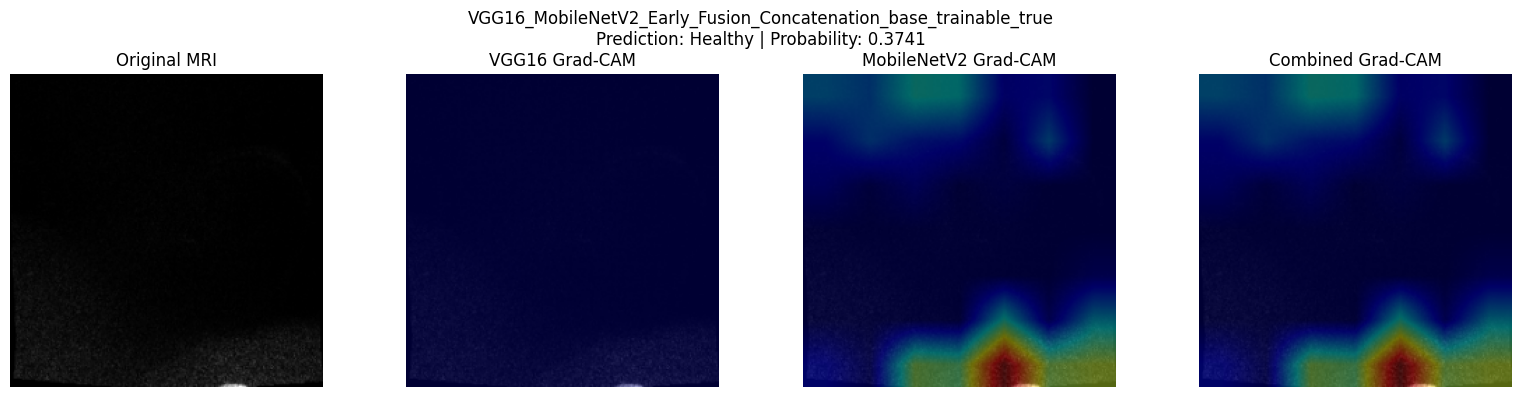

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/gradcam_heatmaps/vgg16_mobilenet_concat_sample_0_true_Healthy_Healthy_prob_0.3741.png


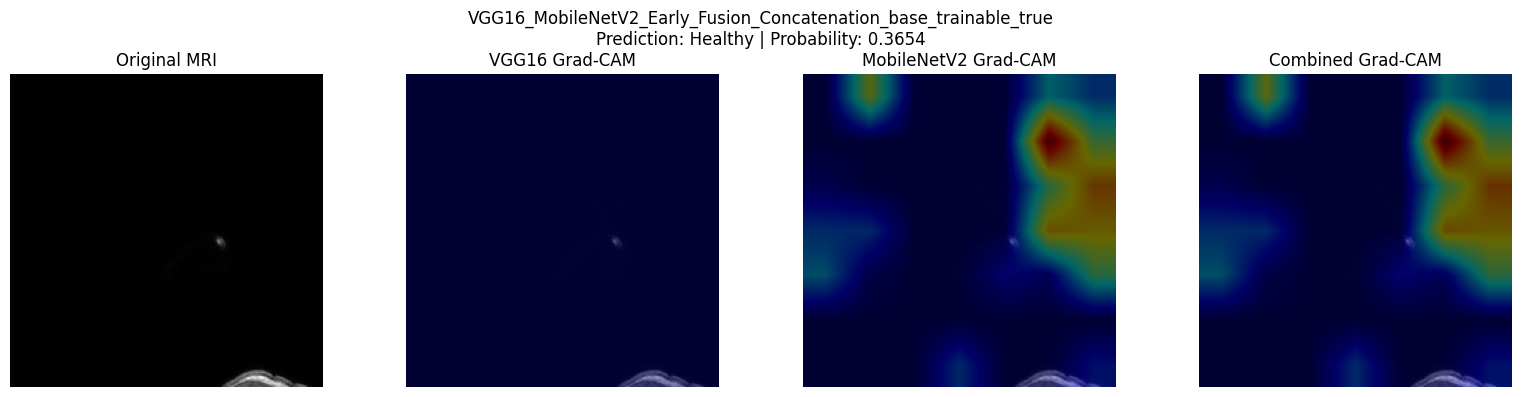

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/gradcam_heatmaps/vgg16_mobilenet_concat_sample_1_true_Healthy_Healthy_prob_0.3654.png


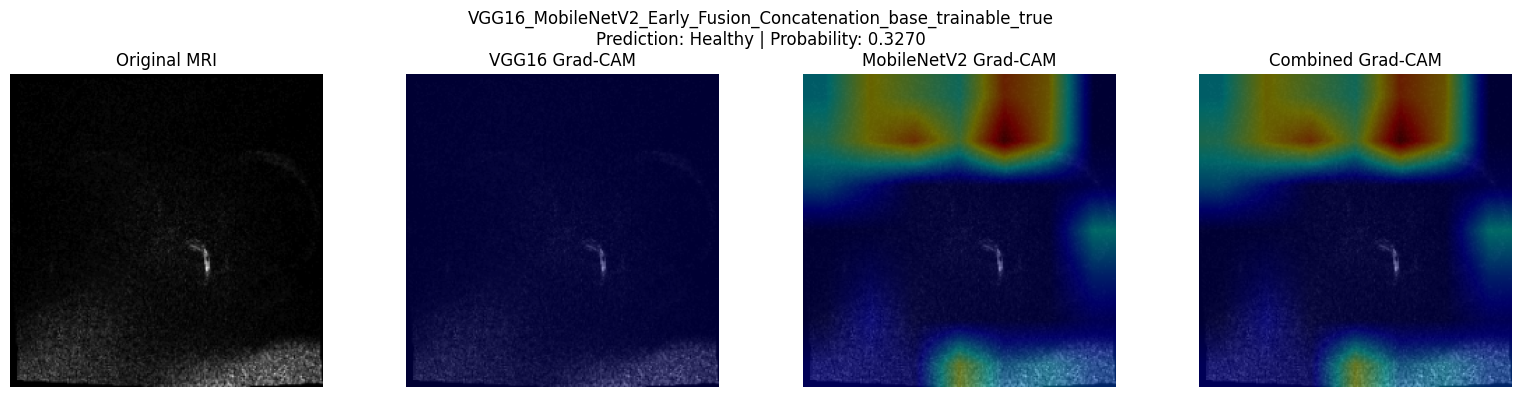

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/gradcam_heatmaps/vgg16_mobilenet_concat_sample_2_true_Healthy_Healthy_prob_0.3270.png


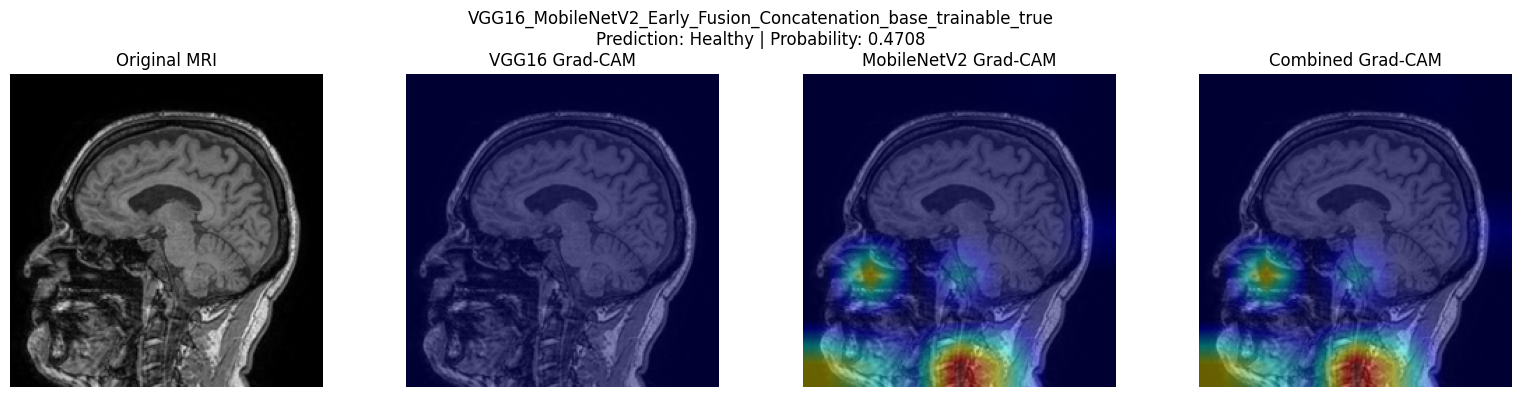

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/gradcam_heatmaps/vgg16_mobilenet_concat_sample_3_true_Parkinson_Healthy_prob_0.4708.png


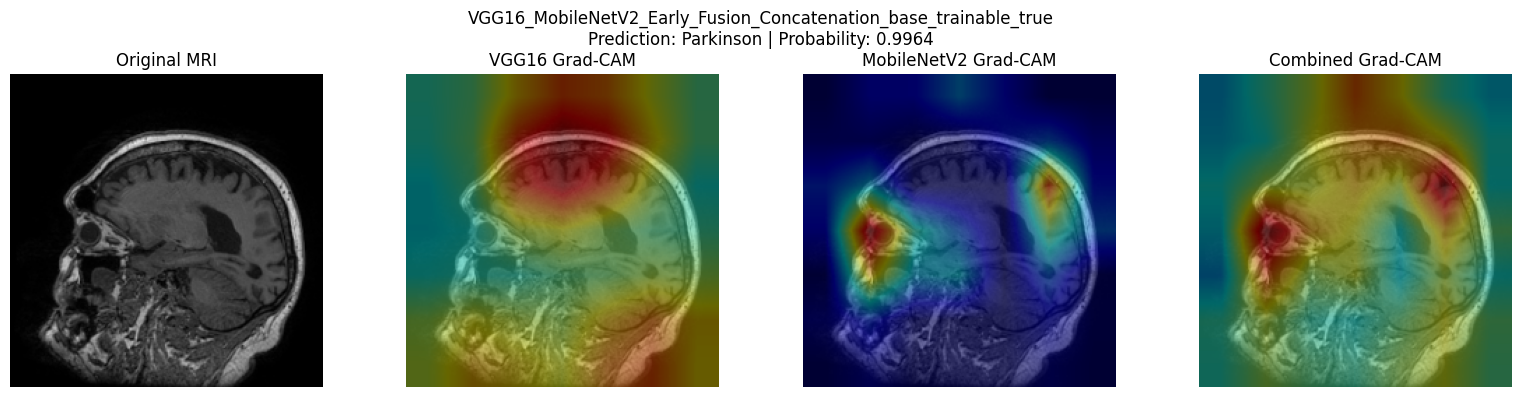

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/gradcam_heatmaps/vgg16_mobilenet_concat_sample_4_true_Parkinson_Parkinson_prob_0.9964.png


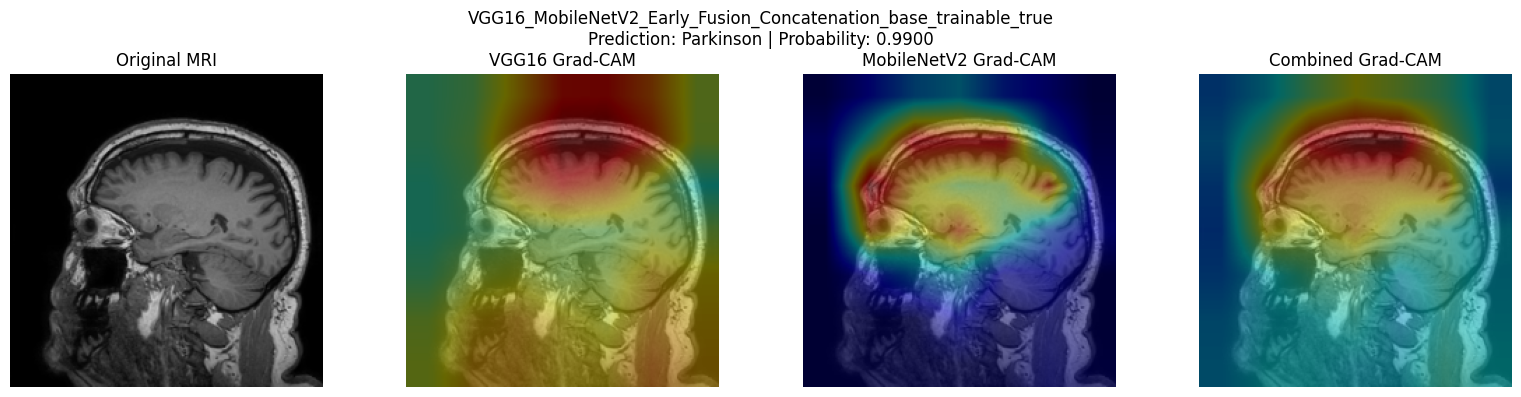

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/gradcam_heatmaps/vgg16_mobilenet_concat_sample_5_true_Parkinson_Parkinson_prob_0.9900.png

Generating Grad-CAM for VGG16 + MobileNetV2 Attention Fusion Model...


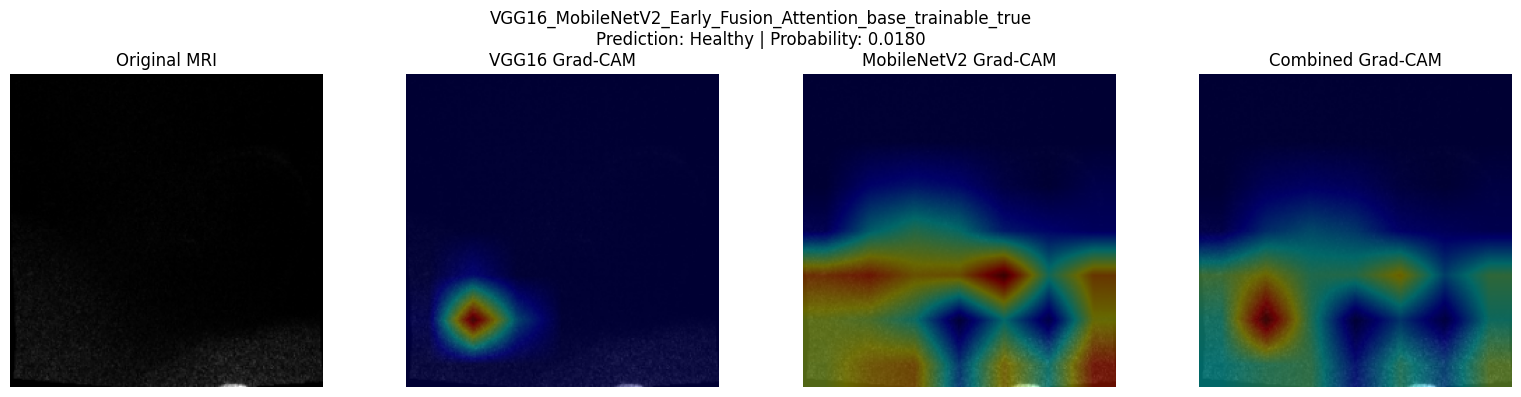

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/gradcam_heatmaps/vgg16_mobilenet_attention_sample_0_true_Healthy_Healthy_prob_0.0180.png


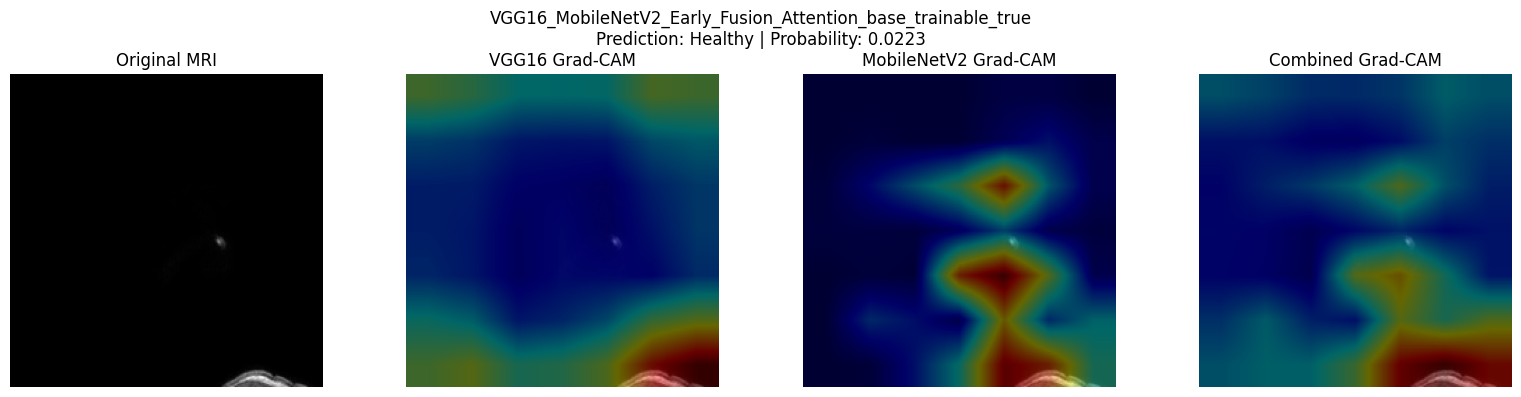

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/gradcam_heatmaps/vgg16_mobilenet_attention_sample_1_true_Healthy_Healthy_prob_0.0223.png


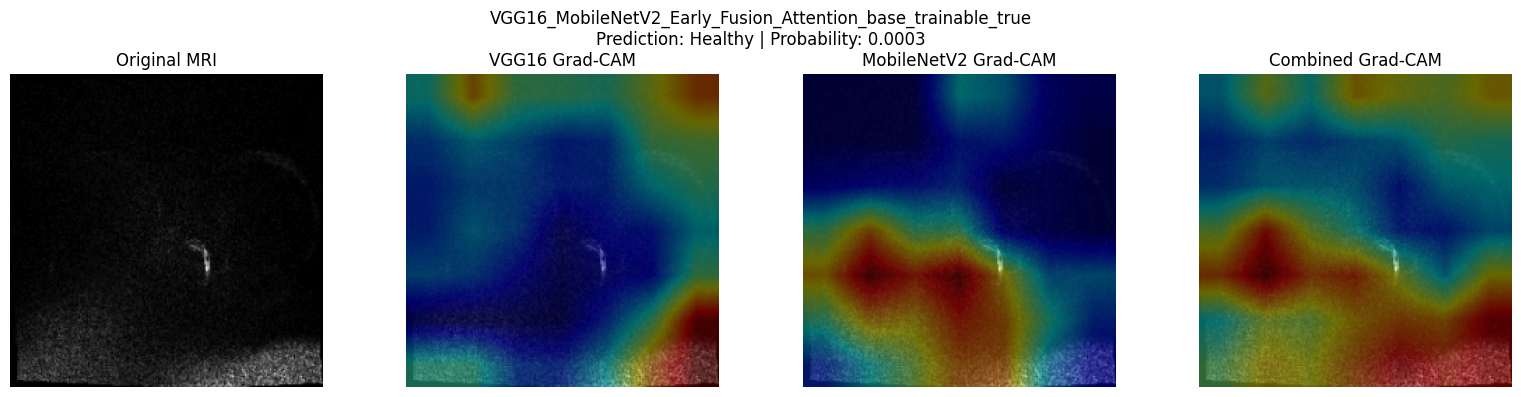

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/gradcam_heatmaps/vgg16_mobilenet_attention_sample_2_true_Healthy_Healthy_prob_0.0003.png


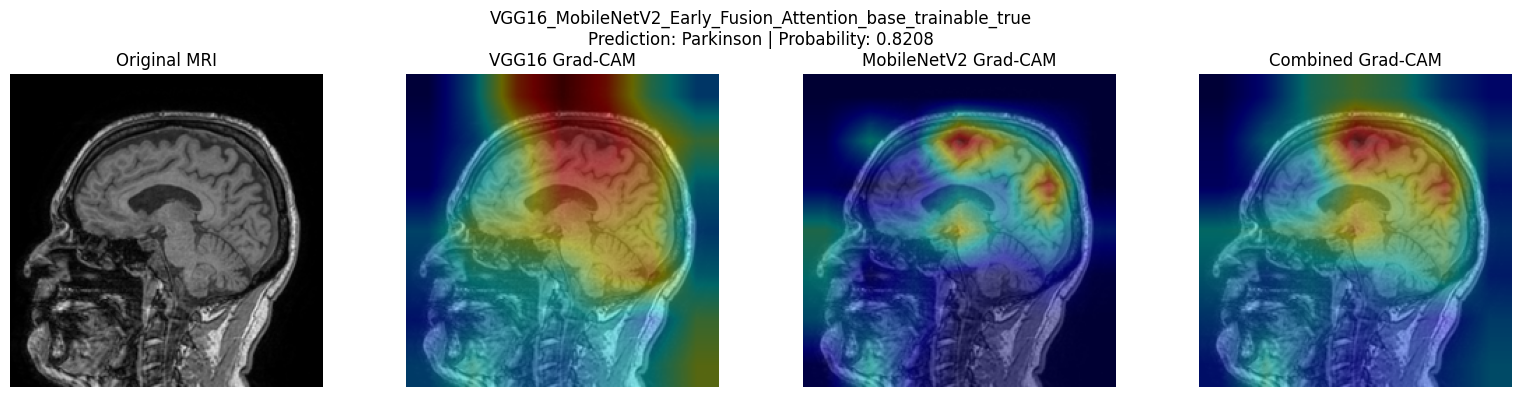

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/gradcam_heatmaps/vgg16_mobilenet_attention_sample_3_true_Parkinson_Parkinson_prob_0.8208.png


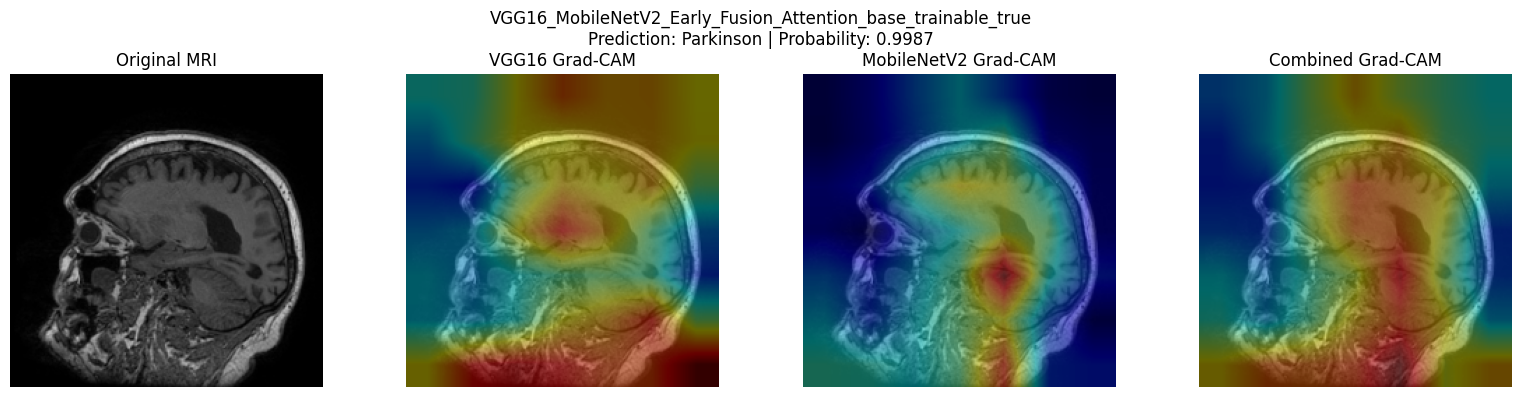

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/gradcam_heatmaps/vgg16_mobilenet_attention_sample_4_true_Parkinson_Parkinson_prob_0.9987.png


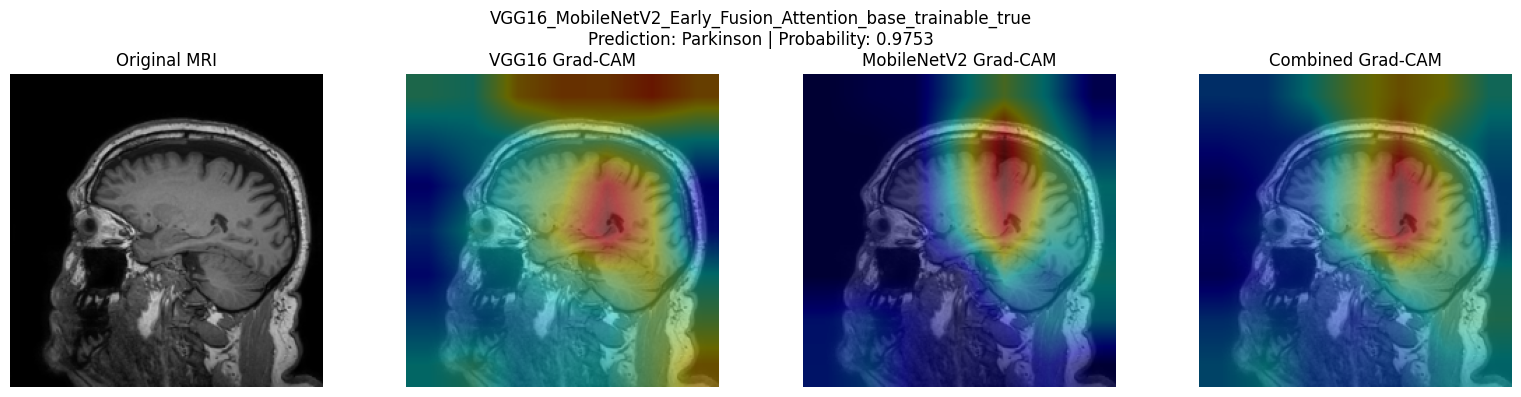

Grad-CAM saved: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/gradcam_heatmaps/vgg16_mobilenet_attention_sample_5_true_Parkinson_Parkinson_prob_0.9753.png


In [ ]:
# ================================
# GENERATE GRAD-CAM FOR TEST IMAGES
# ================================

healthy_samples = test_df[test_df["label"] == "0"].sample(
    n=min(3, len(test_df[test_df["label"] == "0"])),
    random_state=42
)

parkinson_samples = test_df[test_df["label"] == "1"].sample(
    n=min(3, len(test_df[test_df["label"] == "1"])),
    random_state=42
)

gradcam_samples = pd.concat([healthy_samples, parkinson_samples]).reset_index(drop=True)

print("Grad-CAM sample images:")
print(gradcam_samples)


# Grad-CAM for concatenation model
print("\nGenerating Grad-CAM for VGG16 + MobileNetV2 Concatenation Fusion Model...")

for idx, row in gradcam_samples.iterrows():
    image_path = row["image_path"]
    true_label = "Healthy" if row["label"] == "0" else "Parkinson"

    save_fusion_gradcam(
        model=concat_model,
        image_path=image_path,
        model_name=model_name_concat,
        save_prefix=f"vgg16_mobilenet_concat_sample_{idx}_true_{true_label}"
    )


# Grad-CAM for attention model
print("\nGenerating Grad-CAM for VGG16 + MobileNetV2 Attention Fusion Model...")

for idx, row in gradcam_samples.iterrows():
    image_path = row["image_path"]
    true_label = "Healthy" if row["label"] == "0" else "Parkinson"

    save_fusion_gradcam(
        model=attention_model,
        image_path=image_path,
        model_name=model_name_attention,
        save_prefix=f"vgg16_mobilenet_attention_sample_{idx}_true_{true_label}"
    )

In [ ]:
# ================================
# CHECK SAVED OUTPUTS
# ================================

print("Models saved in:", MODEL_DIR)
print(os.listdir(MODEL_DIR))

print("\nGraphs saved in:", GRAPH_DIR)
print(os.listdir(GRAPH_DIR))

print("\nConfusion matrices saved in:", CM_DIR)
print(os.listdir(CM_DIR))

print("\nReports saved in:", REPORT_DIR)
print(os.listdir(REPORT_DIR))

print("\nHistory files saved in:", HISTORY_DIR)
print(os.listdir(HISTORY_DIR))

print("\nGrad-CAM heatmaps saved in:", GRADCAM_DIR)
print(os.listdir(GRADCAM_DIR))

Models saved in: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/models
['VGG16_MobileNetV2_Early_Fusion_Concatenation_base_trainable_true_best.keras', 'VGG16_MobileNetV2_Early_Fusion_Concatenation_base_trainable_true_final.keras', 'VGG16_MobileNetV2_Early_Fusion_Attention_base_trainable_true_best.keras', 'VGG16_MobileNetV2_Early_Fusion_Attention_base_trainable_true_final.keras']

Graphs saved in: /content/drive/MyDrive/Colab Notebooks/VGG16+MOBILENET_EARLY_FUSION_DATA_SAVE_HERE/graphs
['VGG16_MobileNetV2_Early_Fusion_Concatenation_base_trainable_true_accuracy_vs_epochs.png', 'VGG16_MobileNetV2_Early_Fusion_Concatenation_base_trainable_true_loss_vs_epochs.png', 'VGG16_MobileNetV2_Early_Fusion_Concatenation_base_trainable_true_auc_vs_epochs.png', 'VGG16_MobileNetV2_Early_Fusion_Concatenation_base_trainable_true_roc_curve.png', 'VGG16_MobileNetV2_Early_Fusion_Attention_base_trainable_true_accuracy_vs_epochs.png', 'VGG16_MobileNetV2_Early_Fusion_Attentio